# “Exploring Multi-Armed Bandit Problem in Reinforcement Learning: A Comparative Study of Epsilon-Greedy, UCB, and Thompson Sampling Algorithms”
### Reference: https://github.com/yuumii-san/RL_tutorial_notebook.git

## Objective:
The primary objective in the multi-armed bandit problem is to identify and exploit the arm that, on average, produces the largest reward. This objective necessitates a careful balance between exploring the arms to gather information and exploiting the current best-known arm to maximize rewards. The objective of this project is to determine which algorithm has the best performance using metrics such as cumulative reward and cumulative regret and statistical comparison

### Algorithms We Will Learn Through This Notebook
To tackle the multi-armed bandit problem effectively, we will learn several well-established algorithms, each with its own approach to balancing exploration and exploitation. These algorithms include:

#### Epsilon Greedy Algorithm:
The epsilon-greedy algorithm is a straightforward approach that balances exploration (randomly choosing an arm) and exploitation (choosing the arm with the highest estimated reward). It introduces an exploration parameter, epsilon 
, which governs the trade-off between these two aspects.

#### Upper Confidence Bound (UCB):
The UCB algorithm calculates an upper confidence bound for each arm's reward estimate, choosing the arm with the highest upper bound. This technique leverages uncertainty in reward estimates to guide exploration while favoring arms that are likely to be optimal.

#### Thompson Sampling:
Thompson Sampling is a probabilistic algorithm that models each arm's reward distribution. It samples from these distributions to make decisions, naturally balancing exploration and exploitation by adapting to the observed rewards.

Throughout this notebook, our primary focus will be on these algorithms applied to the discrete reward environment.



#### import section

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

#### functions section

In [2]:
class MultiArmedBandit:
    #A class to represent a multi-armed bandit problem.
    def __init__(self, num_arm, reward_probs):
        # Initialize the multi-armed bandit with the number of arms, reward probabilities, and an optional parameter.
        self.num_arm = num_arm
        self.reward_probs = reward_probs
                
    def run_iteration(self, iters, time_steps):
        rewards_hists = []
        explored_cnts = []

        # Run multi-armed bandit simulation for a specified number of iterations.
        for i in range(iters):
            # Store reward history and total explored count of each arm for each iteration i.
            reward_hist, explored_cnt = self.run_episode(time_steps)
            rewards_hists.append(reward_hist)
            explored_cnts.append(explored_cnt)            
        
        # Compute the average and standard deviation over iterations.
        avg_reward_hist = np.mean(rewards_hists, axis=0)
        std_reward_hist = np.std(rewards_hists, axis=0)
        avg_explored_cnt = np.mean(explored_cnts, axis=0)
        std_explored_cnt = np.std(explored_cnts, axis=0)

        return avg_reward_hist, std_reward_hist, avg_explored_cnt, std_explored_cnt
        
    def run_episode(self, time_steps):
        rewards = []
        exp_reward_prob = np.zeros(self.num_arm)
        explored_cnt = np.zeros(self.num_arm)
        
        # Perform multiple trials in a single episode.
        for trial in range(time_steps):
            arm, reward = self.step()
            exp_reward_prob, explored_cnt = self.update(arm, reward, exp_reward_prob, explored_cnt)
            rewards.append(reward)
        return rewards, explored_cnt

    def step(self):
        # Randomly choose one arm and observe its reward.
        arm = np.random.choice(range(self.num_arm))
        reward = np.random.choice([0, 1], p=[1-self.reward_probs[arm], self.reward_probs[arm]])
        return arm, reward
        
    def update(self, arm, reward, exp_reward_prob, explored_cnt):
        # Update the estimated reward probability for the chosen arm.
        explored_cnt[arm] += 1
        exp_reward_prob[arm] = exp_reward_prob[arm] + (1/explored_cnt[arm] * (reward - exp_reward_prob[arm]))
        return exp_reward_prob, explored_cnt #Return the updated estimated reward probabilities and explored count
    
    
    def plot_algorithm_performance(self, algo, avg_reward_hist, std_reward_hist, avg_explored_cnt, time_steps, best_arm_prob):
        # Create subplots to visualize algorithm performance metrics.
        plt.figure(figsize=(20,5))

        # Plot average reward over time steps.
        plt.subplot(1,3,1)
        plt.plot(list(range(time_steps)), avg_reward_hist, color='b')
        plt.axhline(y=best_arm_prob, color='r')
        plt.ylim([0, 1])
        plt.xlabel('Time steps', fontsize=fontsize)
        plt.ylabel('Avg. reward at each time step', fontsize=fontsize)

        # Plot average reward across all time steps.
        plt.subplot(1,3,2)
        avg_reward = [np.mean(avg_reward_hist), best_arm_prob]
        std_reward = [np.std(avg_reward_hist), 0]
        plt.bar([algo, 'Best'], avg_reward, yerr=std_reward, color='gray')
        plt.ylim([0, 1])
        plt.xticks(fontsize=fontsize)
        plt.ylabel('Avg. reward over time steps', fontsize=fontsize)

        # Plot average explored count for each arm.
        plt.subplot(1,3,3)
        arm_labels =  [str(x) for x in range(self.num_arm)]
        plt.bar(arm_labels, avg_explored_cnt, color='gray')
        plt.xticks(fontsize=fontsize)
        plt.ylabel('Avg. explored trial count', fontsize=fontsize)
        

In [3]:
class EpsilonGreedy(MultiArmedBandit):
    def __init__(self, num_arm, reward_probs, epsilon):
        # Initialize the Epsilon Greedy algorithm with the number of arms, reward probabilities, and epsilon.
        super().__init__(num_arm, reward_probs)
        self.epsilon = epsilon

    def run_episode(self, time_steps):
        rewards = []
        exp_reward_prob = np.zeros(self.num_arm)
        explored_cnt = np.zeros(self.num_arm)

        # Perform multiple trials in a single episode.
        for trial in range(time_steps):
            # Use exp_reward_prob to decide the next arm.
            arm, reward = self.step(exp_reward_prob)
            exp_reward_prob, explored_cnt = self.update(arm, reward, exp_reward_prob, explored_cnt)
            rewards.append(reward)
        return rewards, explored_cnt

    def step(self, exp_reward_prob):
        p = np.random.random()  # Generate a random number in the range (0, 1).
        if p < self.epsilon:  # Exploration: Choose a random arm.
            arm = np.random.choice(self.num_arm)
        else:  # Exploitation: Choose the arm with the highest expected reward (break ties randomly).
            greedy_arm_indices = np.where(exp_reward_prob == exp_reward_prob.max())[0]
            arm = np.random.choice(greedy_arm_indices)
        reward = np.random.choice([0, 1], p=[1 - self.reward_probs[arm], self.reward_probs[arm]])
        return arm, reward #The chosen arm and its reward.

In [4]:
class ThompsonSampling(MultiArmedBandit):
    def __init__(self, num_arm, reward_probs, prior=None):
        super().__init__(num_arm, reward_probs)
        self.prior = prior if prior else [(1, 1)] * num_arm  # Use uniform prior if no prior is provided

    def run_episode(self, time_steps):
        rewards = []
        succ_fail = [list(x) for x in self.prior]  # Deep copy of the prior
        explored_cnt = np.zeros(self.num_arm)
        
        for trial in range(time_steps):
            arm, reward = self.step(succ_fail, explored_cnt)
            succ_fail, explored_cnt = self.update(arm, reward, succ_fail, explored_cnt)
            rewards.append(reward)
        return rewards, explored_cnt

    def step(self, succ_fail, explored_cnt):
        #Choose an arm based on the Thompson Sampling algorithm and observe its reward
        samples = [np.random.beta(s + 1, f + 1) for s, f in succ_fail]
        arm = np.argmax(samples)
        reward = np.random.choice([0, 1], p=[1 - self.reward_probs[arm], self.reward_probs[arm]])
        return arm, reward

    def update(self, arm, reward, succ_fail, explored_cnt):
        # Update the success and failure counts for the chosen arm
        explored_cnt[arm] += 1
        if reward == 0:  # No reward trial
            succ_fail[arm][1] += 1
        elif reward == 1:  # Reward trial
            succ_fail[arm][0] += 1
        return succ_fail, explored_cnt #The updated success and failure counts and explored count

In [5]:
class UCB(MultiArmedBandit):
    def __init__(self, num_arm, reward_probs, c):
        super().__init__(num_arm, reward_probs)
        self.c = c

    def run_episode(self, time_steps):
        rewards = []
        exp_reward_prob = np.zeros(self.num_arm)
        explored_cnt = np.zeros(self.num_arm)
        
        # Perform multiple trials in a single episode.
        for trial in range(time_steps):
            # Use exp_reward_prob to decide the next arm.
            arm, reward = self.step(exp_reward_prob, trial, explored_cnt)
            exp_reward_prob, explored_cnt = self.update(arm, reward, exp_reward_prob, explored_cnt)
            rewards.append(reward)
        return rewards, explored_cnt

    def step(self, exp_reward_prob, trial, explored_cnt):
        if trial < self.num_arm:  # For the first few trials, explore each arm once
            arm = trial
        else:
            ucb_values = exp_reward_prob + self.c * np.sqrt(2 * np.log(trial+1) / (explored_cnt + 1e-5))  # Added a small constant to prevent division by zero
            arm = np.argmax(ucb_values)
        
        reward = np.random.choice([0, 1], p=[1 - self.reward_probs[arm], self.reward_probs[arm]])
        return arm, reward # The chosen arm and its reward.

In [6]:
def plot_cumulative_metrics(algorithms, labels, num_trial, best_arm_prob):
    plt.figure(figsize=(20,10))

    # Plot cumulative reward over time steps
    plt.subplot(1,2,1)
    for avg_rewards, label in zip(algorithms, labels):
        plt.plot(list(range(num_trial)), np.cumsum(avg_rewards), label=label)
    plt.axhline(y=best_arm_prob*num_trial, color='r', linestyle='--', label='Best Possible')
    plt.xlabel('Time steps', fontsize=fontsize)
    plt.ylabel('Cumulative reward', fontsize=fontsize)
    plt.legend()

    # Plot cumulative regret over time steps
    plt.subplot(1,2,2)
    for avg_rewards, label in zip(algorithms, labels):
        plt.plot(list(range(num_trial)), best_arm_prob*num_trial - np.cumsum(avg_rewards), label=label)
    plt.xlabel('Time steps', fontsize=fontsize)
    plt.ylabel('Cumulative regret', fontsize=fontsize)
    plt.legend()

    plt.tight_layout()
    plt.show()

#### parameter section

In [7]:
fontsize = 15
num_trial = 1000
num_ite = 100
num_arm = 10
arm_labels_str =  [str(x) for x in range(num_arm)]

In [8]:
# Initialize the bandit environment
num_arms = 10  # Number of arms
random_seed = 2023
np.random.seed(random_seed)

# Generate random reward discrete probabilities for each arm
reward_probs = np.random.uniform(0, 1, num_arms)
# Find the index of the arm with the highest reward probability
best_arm_index = np.argmax(reward_probs)

# Create labels for each arm
arm_labels = [str(x) for x in range(num_arms)]

In [9]:
# Epsilon-Greedy parameter optimization
epsilons = [0, 0.01, 0.1, 0.3, 0.5, 1]
avg_rewards_hist_eg = []
avg_rewards_overall_eg = []

In [10]:
# Thompson Sampling parameter optimization
alphas = [0.5, 1, 2, 3, 5]
betas = [0.5, 1, 2, 3, 5]
best_avg_reward_ts = -np.inf
best_alpha, best_beta = None, None

In [11]:
# UCB parameter optimization
cs = [0.1, 0.25, 0.5, 1, 2]
avg_rewards_hist_ucb = []
avg_rewards_overall_ucb = []

#### main program

In [12]:
# Loop through different epsilon values.
for epsilon in epsilons:
    eg = EpsilonGreedy(num_arm, reward_probs, epsilon)
    avg_rewards_eg, _, _, _ = eg.run_iteration(num_ite, num_trial)
    avg_rewards_hist_eg.append(avg_rewards_eg)
    avg_rewards_overall_eg.append(np.mean(avg_rewards_eg))

# Identify the best-performing epsilon value.
best_epsilon_index = np.argmax(avg_rewards_overall_eg)
best_epsilon = epsilons[best_epsilon_index]

print(f"Best epsilon for Epsilon-Greedy: {best_epsilon}")

Best epsilon for Epsilon-Greedy: 0.1


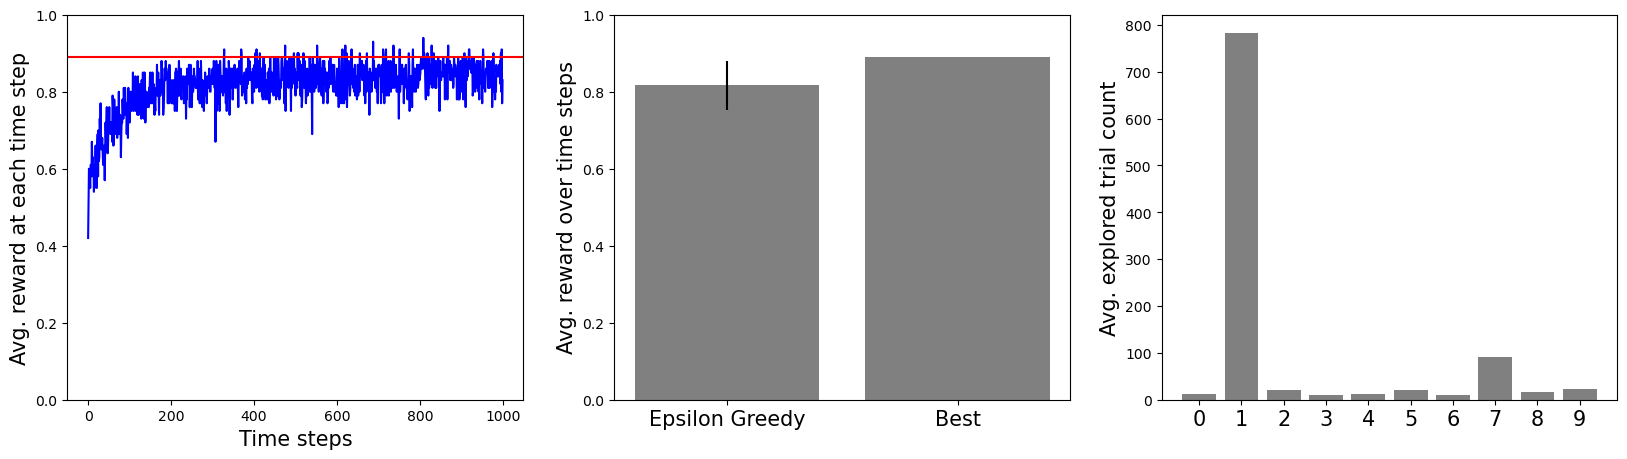

In [13]:
# Run Epsilon-Greedy with the best epsilon
eg = EpsilonGreedy(num_arm, reward_probs, best_epsilon)
avg_rewards_eg, std_rewards_eg, avg_explored_cnt_eg, std_explored_cnt_eg = eg.run_iteration(num_ite, num_trial)

# Plot the results
eg.plot_algorithm_performance('Epsilon Greedy', avg_rewards_eg, std_rewards_eg, avg_explored_cnt_eg, num_trial, reward_probs[best_arm_index])
plt.savefig('epsilon_greedy_performance.png')

In [14]:
# Loop through different alpha and beta values.
for alpha in alphas:
    for beta in betas:
        prior = [(alpha, beta)] * num_arm  # Use the same prior for all arms
        ts = ThompsonSampling(num_arm, reward_probs, prior)
        avg_rewards_ts, _, _, _ = ts.run_iteration(num_ite, num_trial)
        if np.mean(avg_rewards_ts) > best_avg_reward_ts:
            best_avg_reward_ts = np.mean(avg_rewards_ts)
            best_alpha, best_beta = alpha, beta

print(f"Best alpha for Thompson Sampling: {best_alpha}")
print(f"Best beta for Thompson Sampling: {best_beta}")

Best alpha for Thompson Sampling: 1
Best beta for Thompson Sampling: 3


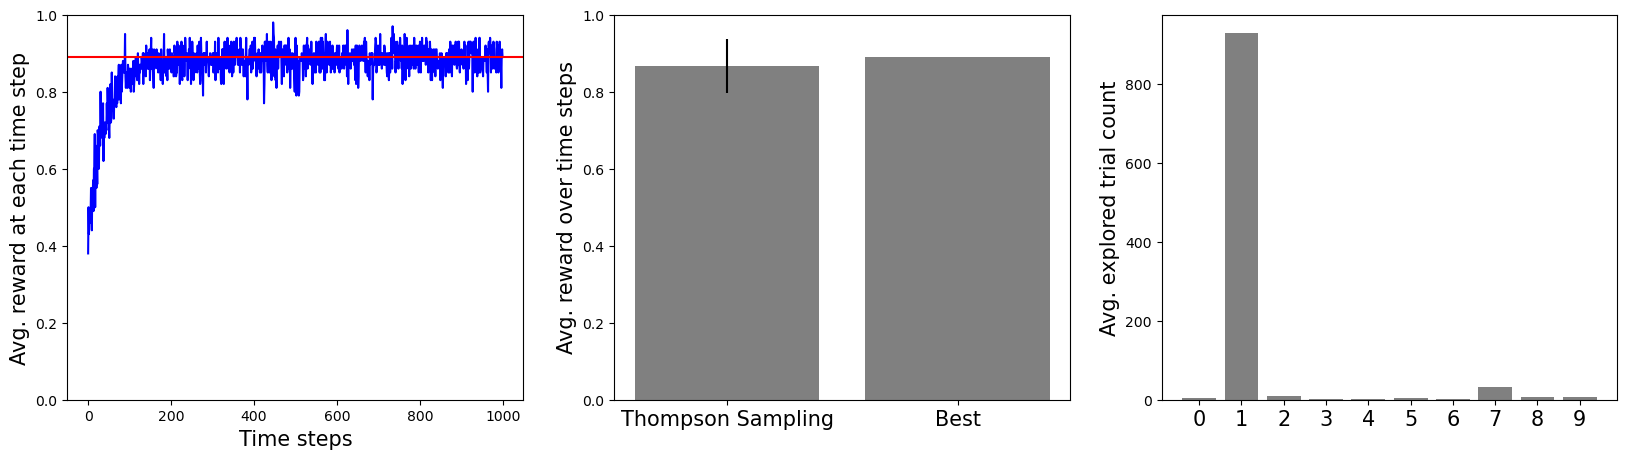

In [15]:
prior = [(best_alpha, best_beta)] * num_arm
ts = ThompsonSampling(num_arm, reward_probs, prior)
avg_rewards_ts, std_rewards_ts, avg_explored_cnt_ts, std_explored_cnt_ts = ts.run_iteration(num_ite, num_trial)
# Plot the performance
ts.plot_algorithm_performance('Thompson Sampling', avg_rewards_ts, std_rewards_ts, avg_explored_cnt_ts, num_trial, reward_probs[best_arm_index])

# Save the figure
plt.savefig('thompson_sampling_performance.png')


In [16]:
# Loop through different c values.
for c in cs:
    ucb = UCB(num_arm, reward_probs, c)
    avg_rewards_ucb, _, _, _ = ucb.run_iteration(num_ite, num_trial)
    avg_rewards_hist_ucb.append(avg_rewards_ucb)
    avg_rewards_overall_ucb.append(np.mean(avg_rewards_ucb))

# Identify the best-performing c value.
best_c_index = np.argmax(avg_rewards_overall_ucb)
best_c = cs[best_c_index]

print(f"Best c for UCB: {best_c}")

Best c for UCB: 0.25


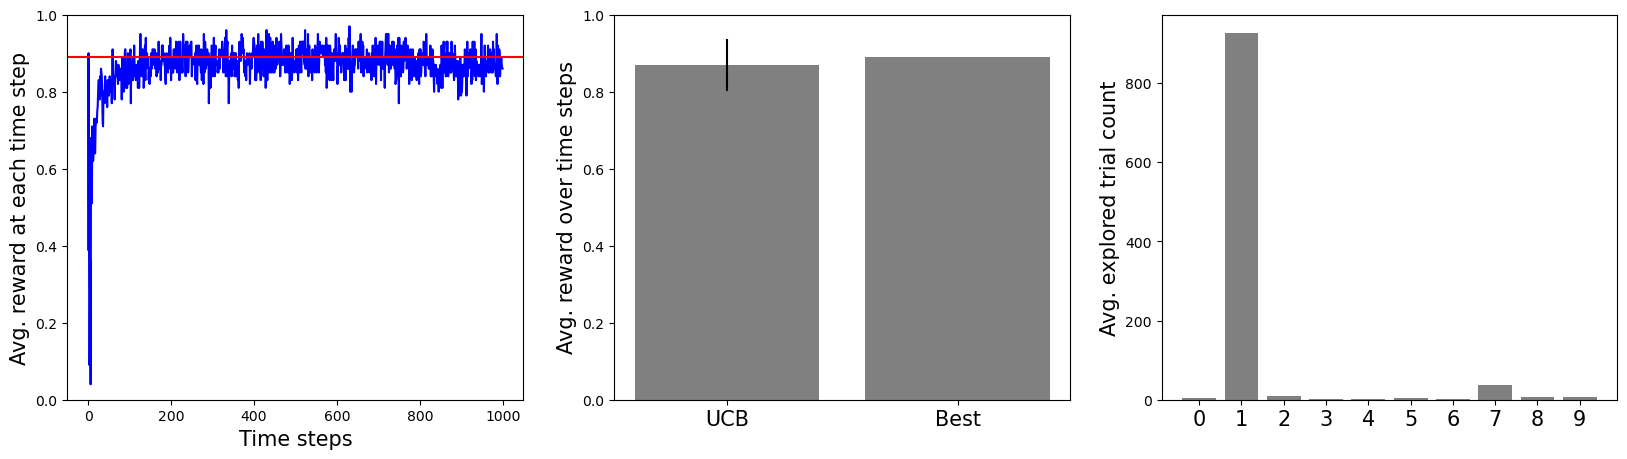

In [17]:
# Run UCB with the best c
ucb = UCB(num_arm, reward_probs, best_c)
avg_rewards_ucb, std_rewards_ucb, avg_explored_cnt_ucb, std_explored_cnt_ucb = ucb.run_iteration(num_ite, num_trial)

# Plot the results
ucb.plot_algorithm_performance('UCB', avg_rewards_ucb, std_rewards_ucb, avg_explored_cnt_ucb, num_trial, reward_probs[best_arm_index])
plt.savefig('ucb_performance.png')

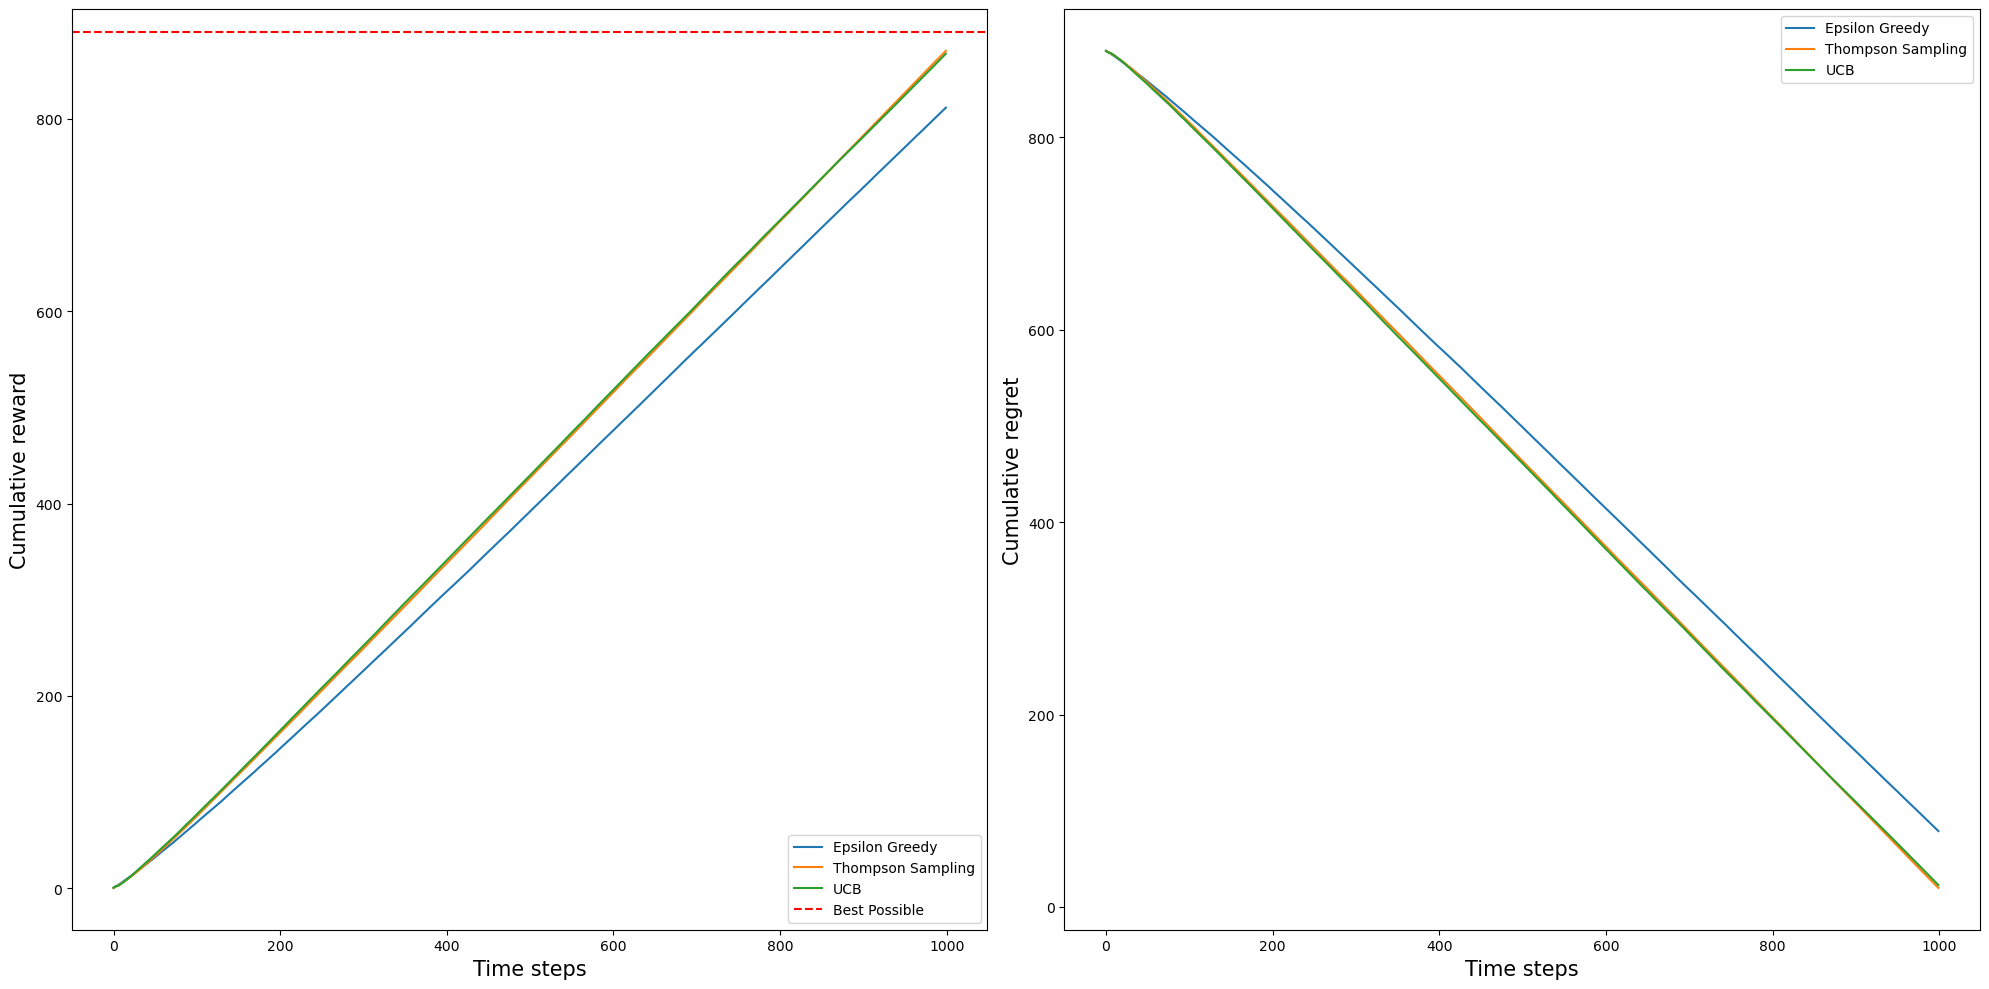

<Figure size 640x480 with 0 Axes>

In [18]:
# Run the algorithms
avg_rewards_eg, _, _, _ = eg.run_iteration(num_ite, num_trial)
avg_rewards_ts, _, _, _ = ts.run_iteration(num_ite, num_trial)
avg_rewards_ucb, _, _, _ = ucb.run_iteration(num_ite, num_trial)

# Plot the cumulative metrics
plot_cumulative_metrics([avg_rewards_eg, avg_rewards_ts, avg_rewards_ucb], ['Epsilon Greedy', 'Thompson Sampling', 'UCB'], num_trial, reward_probs[best_arm_index])
plt.savefig('cumulative_metrics.png')

In [19]:
from scipy import stats

# Perform one-way ANOVA
f_val, p_val = stats.f_oneway(avg_rewards_eg, avg_rewards_ts, avg_rewards_ucb)

print(f"F-value: {f_val}, p-value: {p_val}")


F-value: 250.1204637951786, p-value: 3.486135844437444e-101


In [20]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Concatenate the average rewards
avg_rewards_all = np.concatenate([avg_rewards_eg, avg_rewards_ts, avg_rewards_ucb])

# Create group labels
groups = ['Epsilon-Greedy'] * len(avg_rewards_eg) + ['Thompson Sampling'] * len(avg_rewards_ts) + ['UCB'] * len(avg_rewards_ucb)

# Perform Tukey's HSD test
tukey_results = pairwise_tukeyhsd(avg_rewards_all, groups, alpha=0.05)

print(tukey_results)


           Multiple Comparison of Means - Tukey HSD, FWER=0.05           
      group1            group2      meandiff p-adj   lower  upper  reject
-------------------------------------------------------------------------
   Epsilon-Greedy Thompson Sampling   0.0591    0.0  0.0521 0.0661   True
   Epsilon-Greedy               UCB   0.0561    0.0  0.0492 0.0631   True
Thompson Sampling               UCB  -0.0029 0.5891 -0.0099 0.0041  False
-------------------------------------------------------------------------
